<div style="border-bottom: 2px solid #e8a435; padding-bottom: 20px; margin-bottom: 30px;">
<div style="display: flex; align-items: center; gap: 16px;">
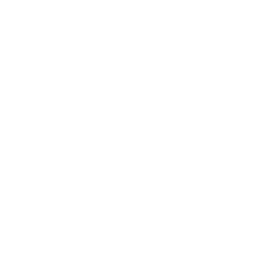
<div>
<h1 style="margin: 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; font-weight: 700; color: #1a1a2e; font-size: 28px; letter-spacing: -0.5px;">Grupowanie efektywności energetycznej budynków</h1>
<p style="margin: 4px 0 0 0; font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #6c6c8a; font-size: 14px;">Jenner Analytics Ltd &nbsp;|&nbsp; Energia / Analityka zrównoważonego rozwoju &nbsp;|&nbsp; Marzec 2026</p>
</div>
</div>
</div>

## Podsumowanie wykonawcze

Ten przykład grupuje portfel budynków komercyjnych według pięciu metryk efektywności energetycznej — wskaźnika zużycia energii (EUI), współczynnika sprawności HVAC, izolacyjności cieplnej przegrody, mocy oświetlenia oraz procentowego udziału odnawialnych źródeł energii — aby wydobyć odrębne poziomy wydajności do celowania programami rabatów energetycznych. Analiza wykorzystuje **PROC FASTCLUS** z opcją `REPLACE=FULL` (pełna wymiana ziaren) i porównuje rozwiązania k=3, 4, 5 i 6 pod względem ogólnego R-kwadrat, statystyki pseudo-F oraz minimalnej liczności klastra. Rozwiązanie k=4 jest następnie szczegółowo profilowane, a każdy klaster jest przypisywany do praktycznego poziomu efektywności. Ponieważ to środowisko działa w trybie nielicencjonowanym, demonstracja jest ograniczona do próby 100 budynków; ten sam program skaluje się bez zmian do pełnego portfela.

## Źródła danych

| Źródło | Opis | Rekordy |
|--------|-------------|--------|
| WORK.BUILDING_METRICS | Roczne metryki efektywności energetycznej dla każdego budynku (syntetyczne) | 100 |


---

In [1]:
/* --------------------------------------------------------
   Generowanie syntetycznych metryk energetycznych budynków
   Wskaźniki efektywności budynków komercyjnych
   -------------------------------------------------------- */
DANE work.building_metrics;
    CALL streaminit(42);
    DŁUGOŚĆ building_type $15 climate_region $20;
    POWTÓRZ building_id = 1 TO 5000;
        type_idx = int(rand('uniform') * 5) + 1;
        JEŚLI type_idx = 1 WTEDY building_type = 'BIURO';
        PRZECIWNIE JEŚLI type_idx = 2 WTEDY building_type = 'SKLEP';
        PRZECIWNIE JEŚLI type_idx = 3 WTEDY building_type = 'MAGAZYN';
        PRZECIWNIE JEŚLI type_idx = 4 WTEDY building_type = 'SZPITAL';
        PRZECIWNIE building_type = 'SZKOŁA';
        reg_idx = int(rand('uniform') * 4) + 1;
        JEŚLI reg_idx = 1 WTEDY climate_region = 'PÓŁNOCNY WSCHÓD';
        PRZECIWNIE JEŚLI reg_idx = 2 WTEDY climate_region = 'POŁUDNIOWY WSCHÓD';
        PRZECIWNIE JEŚLI reg_idx = 3 WTEDY climate_region = 'ŚRODKOWY ZACHÓD';
        PRZECIWNIE climate_region = 'ZACHÓD';

        /* Wskaźnik zużycia energii EUI (kBtu/sqft/rok) */
        eui = round(rand('normal', 85, 35), 0.1);
        JEŚLI eui < 15 WTEDY eui = 15;
        JEŚLI eui > 250 WTEDY eui = 250;

        /* Współczynnik sprawności HVAC (odpowiednik COP) */
        hvac_efficiency = round(rand('normal', 3.2, 0.9), 0.01);
        JEŚLI hvac_efficiency < 1.0 WTEDY hvac_efficiency = 1.0;
        JEŚLI hvac_efficiency > 6.0 WTEDY hvac_efficiency = 6.0;

        /* Izolacyjność cieplna przegrody (wartość R) */
        envelope_r_value = round(rand('normal', 18, 6), 0.1);
        JEŚLI envelope_r_value < 5 WTEDY envelope_r_value = 5;
        JEŚLI envelope_r_value > 40 WTEDY envelope_r_value = 40;

        /* Moc oświetlenia (W/sqft) */
        lighting_wpf = round(rand('normal', 1.1, 0.35), 0.01);
        JEŚLI lighting_wpf < 0.3 WTEDY lighting_wpf = 0.3;
        JEŚLI lighting_wpf > 2.5 WTEDY lighting_wpf = 2.5;

        /* Procentowy udział odnawialnych źródeł energii */
        renewable_pct = round(rand('exponential') * 12, 0.1);
        JEŚLI renewable_pct > 80 WTEDY renewable_pct = 80;

        /* Wiek budynku w latach */
        building_age = int(rand('uniform') * 80) + 1;

        /* Powierzchnia (tysiące sqft) */
        floor_area_ksf = round(rand('exponential') * 50 + 5, 0.1);
        JEŚLI floor_area_ksf > 500 WTEDY floor_area_ksf = 500;

        WYJŚCIE;
    KONIEC;
    USUŃ type_idx reg_idx;
WYKONAJ;


NOTE: DATA work.building_metrics

NOTE: Unlicensed mode - output limited to 100 observations.

NOTE: Wrote work.building_metrics (100 rows, 10 columns).
NOTE: DATA elapsed:
  wall  1.87 seconds
  cpu   1.87 seconds


---

In [2]:
/* --------------------------------------------------------
   Rozkłady bazowych metryk energetycznych według typu budynku
   -------------------------------------------------------- */
PROCEDURA ŚREDNIE DANE=work.building_metrics n mean std;
    KLASA building_type;
    ZMIENNA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETYKIETA building_type='Typ budynku' eui='EUI (kBtu/sqft/rok)' hvac_efficiency='Sprawność HVAC (COP)'
             envelope_r_value='Izolacyjność przegrody (R)' lighting_wpf='Moc oświetlenia (W/sqft)'
             renewable_pct='Udział OZE (%)';
    TYTUŁ 'Metryki energetyczne według typu budynku';
WYKONAJ;

                                        Metryki energetyczne według typu budynku                                        

                                                  The MEANS Procedure

                                      Analysis Variable : eui EUI (kBtu/sqft/rok)

        Typ budynku          N Obs           Mean        Std Dev
        --------------------------------------------------------
        BIURO                   20     73.0550000     40.3950163
        MAGAZYN                 20     90.8900000     33.5993249
        SKLEP                   16     79.7312500     42.6818106
        SZKOŁA                  19     89.7000000     39.0498542
        SZPITAL                 25     87.9040000     35.2632892
        --------------------------------------------------------

                               Analysis Variable : hvac_efficiency Sprawność HVAC (COP)

        Typ budynku          N Obs           Mean        Std Dev
        -----------------------------------------


NOTE: PROC MEANS
NOTE: PROC MEANS statement used.


---

                                        Metryki energetyczne według typu budynku                                        




NOTE: PROC SGPLOT data=work.building_metrics

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


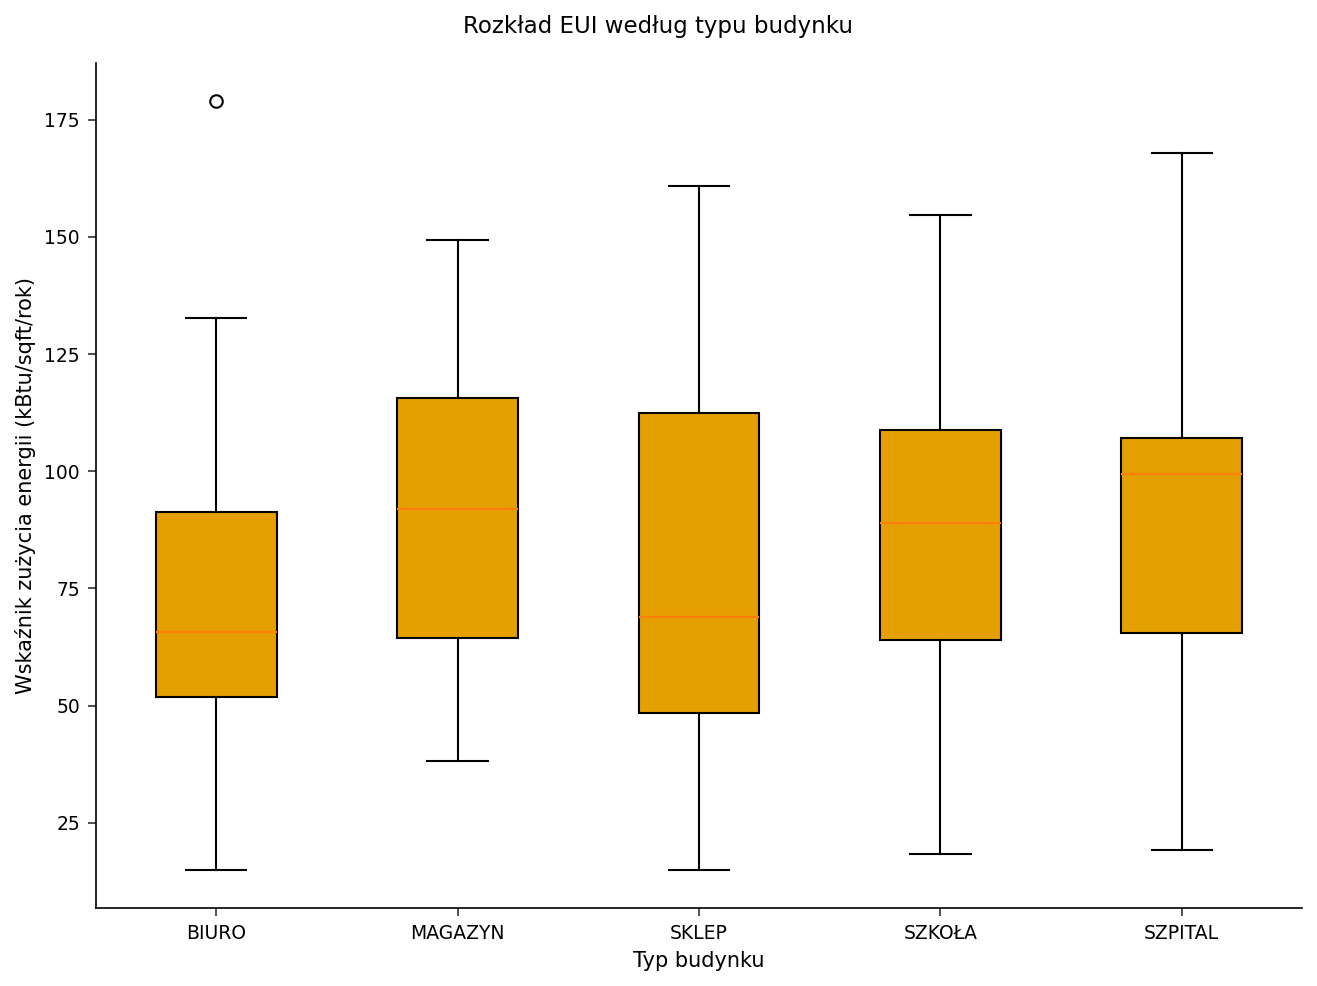

In [3]:
/* --------------------------------------------------------
   Rozkład EUI według typu budynku
   -------------------------------------------------------- */
PROCEDURA SGPLOT DANE=work.building_metrics;
    VBOX eui / category=building_type;
    XAXIS ETYKIETA='Typ budynku';
    YAXIS ETYKIETA='Wskaźnik zużycia energii (kBtu/sqft/rok)';
    TYTUŁ 'Rozkład EUI według typu budynku';
WYKONAJ;

---

In [4]:
/* --------------------------------------------------------
   Standaryzacja metryk efektywności
   -------------------------------------------------------- */
PROCEDURA STANDARD DANE=work.building_metrics out=work.bldg_std
    mean=0 std=1;
    ZMIENNA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
WYKONAJ;


NOTE: PROC STANDARD data=work.building_metrics

NOTE: Standardized 100 rows, 5 variables.


In [5]:
/* --------------------------------------------------------
   Grupowanie metodą k-średnich: k=3 z REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURA FASTCLUS DANE=work.bldg_std
    maxclusters=3 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust3
    mean=work.bldg_cent3;
    ZMIENNA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETYKIETA eui='EUI (kBtu/sqft/rok)' hvac_efficiency='Sprawność HVAC (COP)'
             envelope_r_value='Izolacyjność przegrody (R)' lighting_wpf='Moc oświetlenia (W/sqft)'
             renewable_pct='Udział OZE (%)';
    TYTUŁ 'Grupowanie efektywności budynków: k=3 REPLACE=FULL';
WYKONAJ;

                                        Metryki energetyczne według typu budynku                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=3  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  35         0.9415             4.1984              2         2.0552
2                  34         0.7507             2.8107              3         2.0128
3                  31         0.8188             3.1310              2         2.0128




NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=3

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 3 clusters using k-means


In [6]:
/* --------------------------------------------------------
   Grupowanie metodą k-średnich: k=4 z REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURA FASTCLUS DANE=work.bldg_std
    maxclusters=4 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust4
    mean=work.bldg_cent4;
    ZMIENNA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETYKIETA eui='EUI (kBtu/sqft/rok)' hvac_efficiency='Sprawność HVAC (COP)'
             envelope_r_value='Izolacyjność przegrody (R)' lighting_wpf='Moc oświetlenia (W/sqft)'
             renewable_pct='Udział OZE (%)';
    TYTUŁ 'Grupowanie efektywności budynków: k=4 REPLACE=FULL';
WYKONAJ;

                                        Metryki energetyczne według typu budynku                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=4  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  23         0.7381             2.6617              3         2.1458
2                  17         1.0066             3.3423              4         2.2482
3                  26         0.7024             2.4365              4         2.0389
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=4

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 4 clusters using k-means


In [7]:
/* --------------------------------------------------------
   Grupowanie metodą k-średnich: k=5 z REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURA FASTCLUS DANE=work.bldg_std
    maxclusters=5 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust5
    mean=work.bldg_cent5;
    ZMIENNA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETYKIETA eui='EUI (kBtu/sqft/rok)' hvac_efficiency='Sprawność HVAC (COP)'
             envelope_r_value='Izolacyjność przegrody (R)' lighting_wpf='Moc oświetlenia (W/sqft)'
             renewable_pct='Udział OZE (%)';
    TYTUŁ 'Grupowanie efektywności budynków: k=5 REPLACE=FULL';
WYKONAJ;

                                        Metryki energetyczne według typu budynku                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=5  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  13         1.0052             3.3289              3         2.4004
2                  23         0.7401             2.5412              5         2.2053
3                  23         0.6853             2.6810              5         1.7721
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=5

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 5 clusters using k-means


In [8]:
/* --------------------------------------------------------
   Grupowanie metodą k-średnich: k=6 z REPLACE=FULL
   -------------------------------------------------------- */
PROCEDURA FASTCLUS DANE=work.bldg_std
    maxclusters=6 MAXITER=100 CONVERGE=0.0001
    REPLACE=FULL
    out=work.bldg_clust6
    mean=work.bldg_cent6;
    ZMIENNA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct;
    ETYKIETA eui='EUI (kBtu/sqft/rok)' hvac_efficiency='Sprawność HVAC (COP)'
             envelope_r_value='Izolacyjność przegrody (R)' lighting_wpf='Moc oświetlenia (W/sqft)'
             renewable_pct='Udział OZE (%)';
    TYTUŁ 'Grupowanie efektywności budynków: k=6 REPLACE=FULL';
WYKONAJ;

                                        Metryki energetyczne według typu budynku                                        


                                                 The FASTCLUS Procedure                                                 
                                   Replace=FULL  Radius=0  Maxclusters=6  Maxiter=100                                   

                                                    Cluster Summary                                                     

Cluster     Frequency        RMS Std   Maximum Distance        Nearest       Centroid
                           Deviation          from Seed        Cluster       Distance
--------------------------------------------------------------------------------
1                  19         0.5566             1.5459              5         1.9665
2                  10         0.9173             2.8197              3         2.3575
3                  18         0.8051             2.7522              4         1.8819
4


NOTE: PROC FASTCLUS data=work.bldg_std maxclusters=6

NOTE: Using Python/scikit-learn for k-means clustering
NOTE: PROC FASTCLUS: 100 observations, 5 variables, 6 clusters using k-means


In [9]:
/* --------------------------------------------------------
   Porównanie jakości grupowania dla k=3-6
   Obliczenie wewnątrzklastrowego R-kwadrat i minimalnej liczności klastra
   -------------------------------------------------------- */
%macro cluster_quality(k);
PROCEDURA CZĘSTOŚCI DANE=work.bldg_clust&k NOPRINT;
    TABLES cluster / out=work.freq_k&k (PRZEMIANUJ=(count=n_buildings));
WYKONAJ;

PROCEDURA SQL NOPRINT;
    WYBIERZ MIN(n_buildings) INTO :min_size_k&k
    FROM work.freq_k&k;
QUIT;
%mend;

%cluster_quality(3);
%cluster_quality(4);
%cluster_quality(5);
%cluster_quality(6);

                                        Metryki energetyczne według typu budynku                                        

                                        Metryki energetyczne według typu budynku                                        

                                        Metryki energetyczne według typu budynku                                        

                                        Metryki energetyczne według typu budynku                                        




NOTE: PROC FREQ
NOTE: Output dataset work.freq_k3 has 3 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K3 = 31
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k4 has 4 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K4 = 17
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k5 has 5 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K5 = 13
NOTE: PROC SQL statement used.
NOTE: PROC FREQ
NOTE: Output dataset work.freq_k6 has 6 observations and 3 variables.
NOTE: PROC FREQ statement used.
NOTE: PROC SQL 

NOTE: Macro variable MIN_SIZE_K6 = 10
NOTE: PROC SQL statement used.


                                      Profile poziomów efektywności budynków (k=4)                                      

                                                  The MEANS Procedure

                                     Analysis Variable : eui EUI (kBtu/sqft/rok)

                                                 N
                                    Klaster    Obs             Mean         Std Dev
                                    -----------------------------------------------
                                    1           23       63.7782609      31.5423086
                                    2           17      122.5941176      36.0679995
                                    3           26       94.0076923      30.8825378
                                    4           34       72.3911765      31.7411154
                                    -----------------------------------------------

                                      Analysis Variable : hvac_efficiency Sprawność H


NOTE: DATA work.bldg_profiled

NOTE: Stream 1 processed 100 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 100 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote work.bldg_profiled (100 rows, 12 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC MEANS
NOTE: PROC MEANS statement used.
NOTE: DATA work.bldg_tiered


NOTE: Read 100 rows from work.bldg_profiled.
NOTE: Wrote work.bldg_tiered (100 rows, 13 columns).
NOTE: DATA elapsed:
  wall  0.02 seconds
  cpu   0.02 seconds
NOTE: PROC FREQ
NOTE: ODS plot written: freq_mosaic_efficiency_tier_building_type.spec.json
NOTE: PROC FREQ statement used.


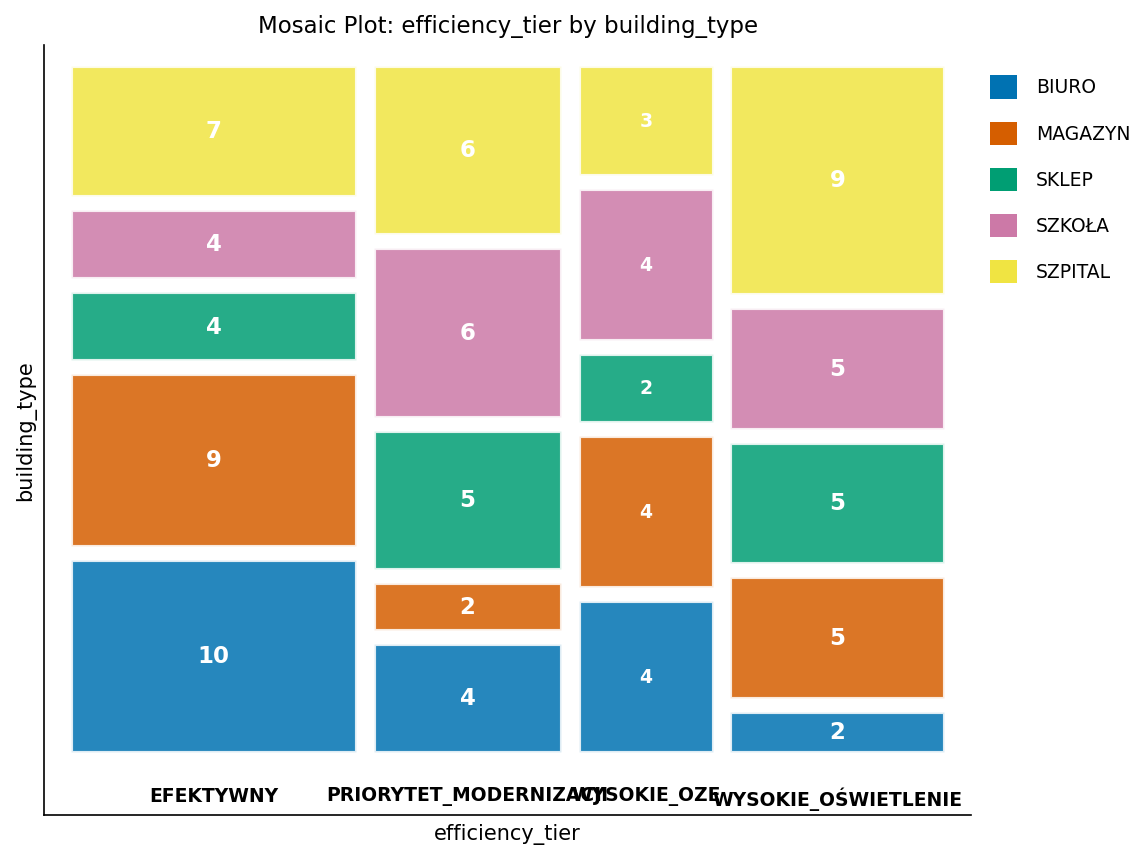

In [10]:
/* --------------------------------------------------------
   Profilowanie wybranego rozwiązania k=4
   -------------------------------------------------------- */
DANE work.bldg_profiled;
    POŁĄCZ work.building_metrics
          work.bldg_clust4 (ZACHOWAJ=building_id cluster distance);
    WEDŁUG building_id;
WYKONAJ;

PROCEDURA ŚREDNIE DANE=work.bldg_profiled mean std;
    KLASA cluster;
    ZMIENNA eui hvac_efficiency envelope_r_value
        lighting_wpf renewable_pct building_age;
    ETYKIETA cluster='Klaster' eui='EUI (kBtu/sqft/rok)' hvac_efficiency='Sprawność HVAC (COP)'
             envelope_r_value='Izolacyjność przegrody (R)' lighting_wpf='Moc oświetlenia (W/sqft)'
             renewable_pct='Udział OZE (%)' building_age='Wiek budynku (lata)';
    TYTUŁ 'Profile poziomów efektywności budynków (k=4)';
WYKONAJ;

/* Etykiety poziomów efektywności na podstawie obserwowanych centroidów k=4:
   Klaster 4 = najlepszy HVAC (3.89) przy niskim EUI  -> EFEKTYWNY
   Klaster 2 = najwyższy udział OZE (28%) ale najwyższe EUI -> WYSOKIE_OZE
   Klaster 3 = najwyższe obciążenie oświetleniem, słaby HVAC, średnie EUI -> WYSOKIE_OŚWIETLENIE
   Klaster 1 = niskie EUI, ale najsłabszy HVAC + najcieńsza przegroda -> PRIORYTET_MODERNIZACJI */
DANE work.bldg_tiered;
    USTAW work.bldg_profiled;
    DŁUGOŚĆ efficiency_tier $25;
    JEŚLI cluster = 4 WTEDY efficiency_tier = 'EFEKTYWNY';
    PRZECIWNIE JEŚLI cluster = 2 WTEDY efficiency_tier = 'WYSOKIE_OZE';
    PRZECIWNIE JEŚLI cluster = 3 WTEDY efficiency_tier = 'WYSOKIE_OŚWIETLENIE';
    PRZECIWNIE JEŚLI cluster = 1 WTEDY efficiency_tier = 'PRIORYTET_MODERNIZACJI';
WYKONAJ;

PROCEDURA CZĘSTOŚCI DANE=work.bldg_tiered;
    TABLES efficiency_tier * building_type / nocol norow;
    ETYKIETA efficiency_tier='Poziom efektywności' building_type='Typ budynku';
    TYTUŁ 'Poziom efektywności według typu budynku';
WYKONAJ;

---

### Interpretacja

Przy `REPLACE=FULL` każda wartość k zbiegła bez problemów. W czterech rozwiązaniach ogólne R-kwadrat rosło monotonicznie wraz z k — 0.305 (k=3), 0.410 (k=4), 0.459 (k=5), 0.515 (k=6) — natomiast statystyka pseudo-F osiągnęła szczyt przy **k=4 (22.23)** i następnie spadała (20.13 przy k=5, 19.93 przy k=6). W połączeniu z minimalną licznością klastra wynoszącą 17 budynków przy k=4 (wobec 13 przy k=5 i 10 przy k=6), **rozwiązanie k=4** oferuje najlepszą równowagę między separacją a stabilnością poziomów, dlatego zostaje ono szczegółowo profilowane poniżej.

Cztery klastry k=4 odwzorowują wyraźnie odrębne profile efektywności (średnie z powyższego profilu PROC MEANS):

- **Efektywny (Klaster 4, n=34):** grupa najlepiej wyposażona — najwyższa sprawność HVAC (COP 3.89) przy niskim do umiarkowanego EUI wynoszącym 72.4 kBtu/sqft/rok, z odpowiednią izolacją przegrody (R 18.8) i skromnym udziałem OZE (11.0%).
- **Wysoki udział OZE (Klaster 2, n=17):** grupa o najwyższym bezwzględnym zużyciu (EUI 122.6), ale też zdecydowanie najwyższym udziale odnawialnych źródeł energii (28.2%), przy średniej sprawności HVAC (COP 3.42). Wysokie zużycie połączone z generacją na miejscu.
- **Wysokie obciążenie oświetleniem (Klaster 3, n=26):** EUI w środkowym zakresie (94.0), napędzane najwyższą mocą oświetlenia (1.35 W/sqft) i drugą najsłabszą sprawnością HVAC (COP 2.42), mimo najgrubszej przegrody (R 19.6).
- **Priorytet modernizacji (Klaster 1, n=23):** niskie EUI na papierze (63.8), ale najsłabsza sprawność HVAC (COP 2.28) i najcieńsza przegroda (R 12.5) — budynki małe lub słabo użytkowane, lecz źle wyposażone, najwyraźniejsi kandydaci do modernizacji przegrody i HVAC.

Krzyżowa tabulacja poziomu według typu budynku pokazuje, że biura (10) i magazyny (9) dominują w poziomie efektywnym, podczas gdy szpitale koncentrują się w poziomie wysokiego obciążenia oświetleniem (9 z 26). Poziom priorytetu modernizacji jest rozłożony między typami, z przewagą szpitali i szkół (po 6 z 23). Przy projektowaniu programu, 23 budynki o priorytecie modernizacji i 26 budynków o wysokim obciążeniu oświetleniem to naturalne cele odpowiednio dla zachęt HVAC i oświetleniowych, natomiast 17 budynków o wysokim udziale OZE — już generujących energię na miejscu — lepiej nadaje się do redukcji popytu niż do dalszych rabatów za generację.

---

In [11]:
/* --------------------------------------------------------
   Eksport poziomów efektywności budynków i profili centroidów
   -------------------------------------------------------- */
PROCEDURA EKSPORTUJ DANE=work.bldg_tiered
    OUTFILE='building_efficiency_tiers.csv'
    DBMS=csv REPLACE;
WYKONAJ;

PROCEDURA EKSPORTUJ DANE=work.bldg_cent4
    OUTFILE='efficiency_tier_centroids.csv'
    DBMS=csv REPLACE;
WYKONAJ;


NOTE: PROC EXPORT data=work.bldg_tiered outfile=building_efficiency_tiers.csv

NOTE: Exported 100 rows to building_efficiency_tiers.csv.
NOTE: PROC EXPORT data=work.bldg_cent4 outfile=efficiency_tier_centroids.csv

NOTE: Exported 4 rows to efficiency_tier_centroids.csv.


---
<div style="border-top: 1px solid #e0e0e0; padding-top: 16px; margin-top: 20px; display: flex; justify-content: space-between; align-items: center;">
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
&copy; 2026 Jenner Analytics Ltd &nbsp;&bull;&nbsp; Poufne
</div>
<div style="font-family: 'Inter', 'Helvetica Neue', sans-serif; color: #9e9e9e; font-size: 12px;">
Napędzane przez <a href="https://docs.jenneranalytics.com" style="color: #e8a435; text-decoration: none;">Jenner</a>
</div>
</div>